# Problem 4
## a)

In [3]:
import random

points = range(21)
p_values = [0.3, 0.5, 0.7]
mc_runs = 20000
p_ruin = {point: {p: 0 for p in p_values} for point in points}

def ruin(p, n):
    tau = 0
    while n > 0 and n < 20:
        R = random.random()
        if R < p: # success rate of +1
            n += 1
        else:
            n -= 1
        
        tau += 1
    
    return tau, n == 0      # return time to ruin and whether it ended at 0

for point in points:
    for p in p_values:
        for _ in range(mc_runs):
            tau, final_0 = ruin(p, point)
            p_ruin[point][p] += final_0     # count how many times it ended at 0
            #print(f"Starting point: {point}, p: {p}, tau: {tau}, End at 0?: {final_0}")
        p_ruin[point][p] /= mc_runs     # average over runs

## b)

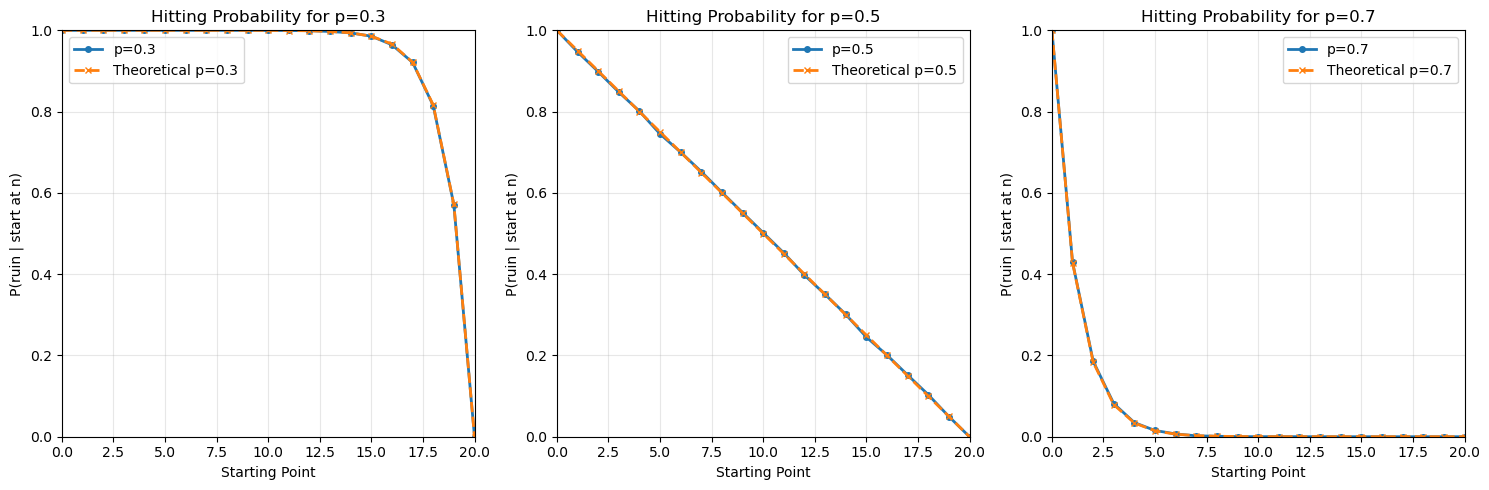


Sample Hitting Probabilities:
Starting Point  p=0.3      p=0.5      p=0.7     
--------------------------------------------------
0               1.0000     1.0000     1.0000    
5               1.0000     0.7450     0.0154    
10              0.9998     0.5019     0.0001    
15              0.9856     0.2452     0.0000    
20              0.0000     0.0000     0.0000    

Theoretical Hitting Probabilities:
Starting Point  p=0.3      p=0.5      p=0.7     
--------------------------------------------------
0               1.0000     1.0000     1.0000    
5               1.0000     0.7500     0.0145    
10              0.9998     0.5000     0.0002    
15              0.9855     0.2500     0.0000    
20              -0.0000    0.0000     0.0000    


In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, p in enumerate(p_values):
    ax = axes[idx]
    
    # Extract probabilities for this p value
    starting_points = list(points)
    probabilities = [p_ruin[point][p] for point in starting_points]
    theoretical_probabilities = [(((1-p)/p)**point - ((1-p)/p)**20) / (1 - ((1-p)/p)**20) for point in starting_points] if p != 0.5 else [(20 - point) / 20 for point in starting_points]
    
    # Plot with lines connecting the points
    ax.plot(starting_points, probabilities, marker='o', markersize=4, 
            linewidth=2, label=f'p={p}')
    ax.plot(starting_points, theoretical_probabilities, marker='x', markersize=4, 
            linewidth=2, label=f'Theoretical p={p}', linestyle='--')
    
    ax.set_xlabel('Starting Point')
    ax.set_ylabel('P(ruin | start at n)')
    ax.set_title(f'Hitting Probability for p={p}')
    ax.set_xlim(0, 20)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

# Print some sample values
print("\nSample Hitting Probabilities:")
print(f"{'Starting Point':<15} {'p=0.3':<10} {'p=0.5':<10} {'p=0.7':<10}")
print("-" * 50)
for point in [0, 5, 10, 15, 20]:
    print(f"{point:<15} {p_ruin[point][0.3]:<10.4f} {p_ruin[point][0.5]:<10.4f} {p_ruin[point][0.7]:<10.4f}")

# Theoretical values for comparison
print("\nTheoretical Hitting Probabilities:")
print(f"{'Starting Point':<15} {'p=0.3':<10} {'p=0.5':<10} {'p=0.7':<10}")
print("-" * 50)
for point in [0, 5, 10, 15, 20]:
    theoretical_03 = (((1-0.3)/0.3)**point - ((1-0.3)/0.3)**20) / (1 - ((1-0.3)/0.3)**20)
    theoretical_05 = (20 - point) / 20
    theoretical_07 = (((1-0.7)/0.7)**point - ((1-0.7)/0.7)**20) / (1 - ((1-0.7)/0.7)**20)
    print(f"{point:<15} {theoretical_03:<10.4f} {theoretical_05:<10.4f} {theoretical_07:<10.4f}")

## c)
The accuracy is the worst when $p=1/2$. This makes sense because with that probability, there is no drift to one direction, so it is more difficult to predict which end the walk will eventually end up on. Interestingly, the worst accuract appears to occur around 5, where I would expect it to occur at 10. The accuracy is very close for $p\neq 1/2$.

# Problem 5

In [5]:
import numpy as np

def make_path(p, N=10000):
    path = [0] * N
    max_s = 0
    min_s = 0
    max_means = []
    min_means = []
    mu = 2 * p - 1
    sigma = np.sqrt(4 * p * (1 - p))
    cone_counts = []


    for i in range(1, N):
        R = random.random()
        if R < p: # success rate of +1
            path[i] = path[i-1] + 1
            if path[i] > max_s:
                max_s = path[i]
        else:
            path[i] = path[i-1] - 1
            if path[i] < min_s:
                min_s = path[i]

        max_means.append(max_s / i)
        min_means.append(min_s / i)



        if np.abs(path[i] - mu * i) > 3 * sigma * np.sqrt(i): # if outside the 3sigma cone
            cone_counts.append(1) # for probability later
        else:
            cone_counts.append(0)


    return path, max_means, min_means, cone_counts


M_runs = 2000
paths = {p: [] for p in p_values}
for p in p_values:
    for _ in range(M_runs):
        path, max_means, min_means, cone_counts = make_path(p)
        paths[p].append((path, max_means, min_means, cone_counts))

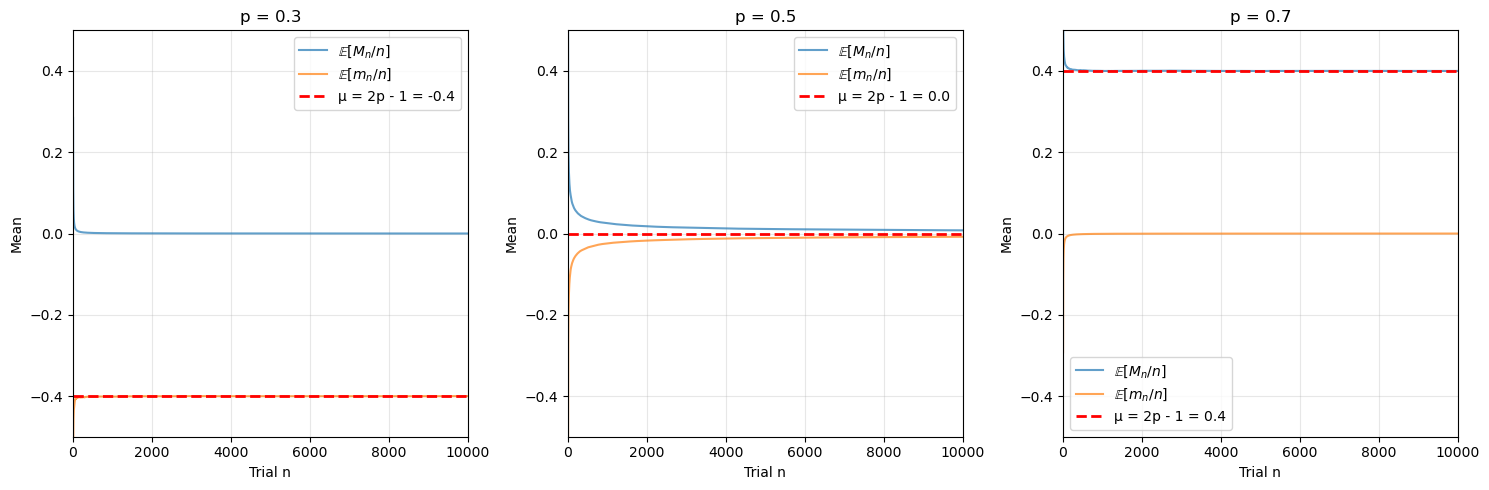

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, p in enumerate(p_values):
    ax = axes[idx]
    
    # Calculate empirical averages across all M runs
    N = 9999  # Length of max_means and min_means
    empirical_max_means = np.zeros(N)
    empirical_min_means = np.zeros(N)
    
    for path, max_means, min_means, _ in paths[p]:
        empirical_max_means += np.array(max_means)
        empirical_min_means += np.array(min_means)
    
    # Average over M runs
    empirical_max_means /= M_runs
    empirical_min_means /= M_runs
    
    # Plot empirical means
    trials = np.arange(1, N + 1)
    ax.plot(trials, empirical_max_means, label=r'$\mathbb{E}[M_n/n]$', 
            alpha=0.7, linewidth=1.5)
    ax.plot(trials, empirical_min_means, label=r'$\mathbb{E}[m_n/n]$', 
            alpha=0.7, linewidth=1.5)
    
    # Plot theoretical drift line μ = 2p - 1
    mu = 2*p - 1
    ax.axhline(y=mu, color='red', linestyle='--', linewidth=2, 
               label=f'μ = 2p - 1 = {mu:.1f}')
    
    ax.set_xlabel('Trial n')
    ax.set_ylabel('Mean')
    ax.set_title(f'p = {p}')
    ax.set_xlim(0, 10000)
    ax.set_ylim(-0.5, 0.5)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

For varying $p$, the theoretical drift line aligns with the trend of the path. In other words, as time goes to infinity, we could expect the path to more closely look like a straight line with slope $\mu$. Additionally, the max and mins for skewed probabilities' graphs are close to 0, which was the starting point.

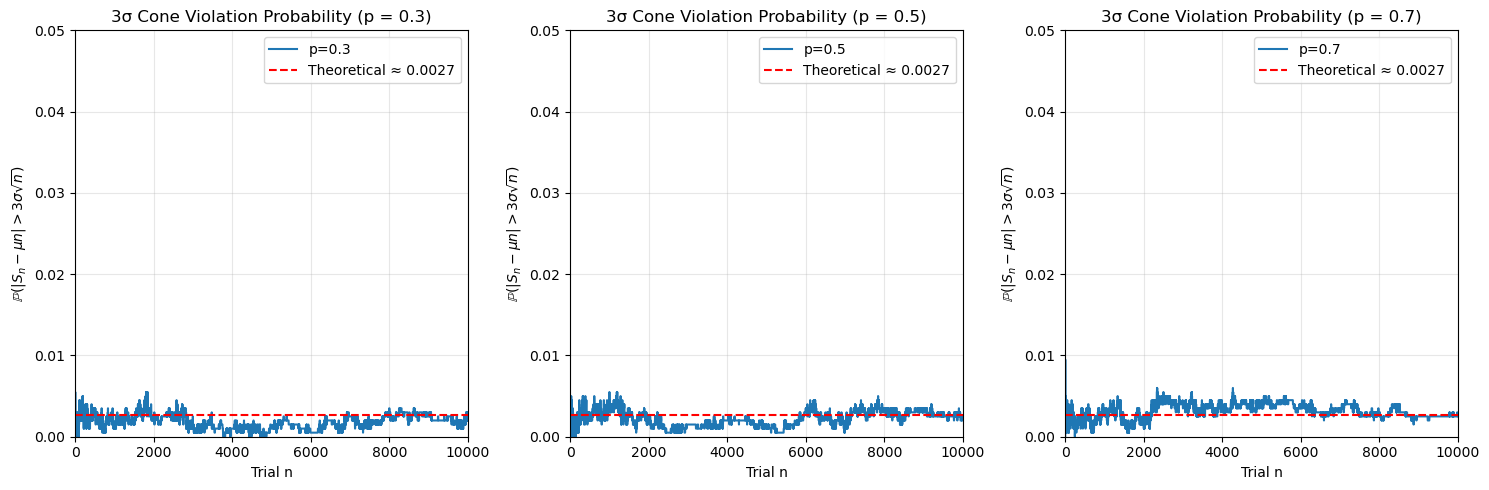


3σ Cone Violation Summary:
p          Prob at n=1000       Prob at n=5000       Prob at n=9999      
----------------------------------------------------------------------
0.3        0.0010               0.0010               0.0025              
0.5        0.0050               0.0015               0.0025              
0.7        0.0030               0.0035               0.0025              


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, p in enumerate(p_values):
    ax = axes[idx]
    
    # Calculate empirical probability P(|S_n - μn| > 3σ√n) across all M runs
    N = 9999  # Length of cone_counts
    cone_probs = np.zeros(N)
    
    for path, max_means, min_means, cone_counts in paths[p]:
        cone_probs += np.array(cone_counts)
    
    # Average over M runs to get probability at each n
    cone_probs /= M_runs
    
    # Plot probability as a function of n
    trials = np.arange(1, N + 1)
    ax.plot(trials, cone_probs, linewidth=1.5, label=f'p={p}')
    
    ax.set_xlabel('Trial n')
    ax.set_ylabel(r'$\mathbb{P}(|S_n - \mu n| > 3\sigma\sqrt{n})$')
    ax.set_title(f'3σ Cone Violation Probability (p = {p})')
    ax.set_xlim(0, 10000)
    ax.set_ylim(0, 0.05)  # Should be small (near 0.003 theoretically)
    ax.axhline(y=0.0027, color='red', linestyle='--', label='Theoretical ≈ 0.0027')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary
print("\n3σ Cone Violation Summary:")
print(f"{'p':<10} {'Prob at n=1000':<20} {'Prob at n=5000':<20} {'Prob at n=9999':<20}")
print("-" * 70)
for p in p_values:
    cone_probs = np.zeros(9999)
    for path, max_means, min_means, cone_counts in paths[p]:
        cone_probs += np.array(cone_counts)
    cone_probs /= M_runs
    
    print(f"{p:<10} {cone_probs[999]:<20.4f} {cone_probs[4999]:<20.4f} {cone_probs[9998]:<20.4f}")

In [8]:
# Calculate average probability across all n for each p
print("\nAverage 3σ Cone Violation Probability:")
print(f"{'p':<10} {'Average Prob':<20} {'Theoretical':<20} {'Difference':<20}")
print("-" * 70)

theoretical_prob = 0.0027  # P(|Z| > 3) for standard normal ≈ 0.0027

for p in p_values:
    cone_probs = np.zeros(9999)
    for path, max_means, min_means, cone_counts in paths[p]:
        cone_probs += np.array(cone_counts)
    cone_probs /= M_runs
    
    # Average probability across all time points
    avg_prob = np.mean(cone_probs)
    diff = avg_prob - theoretical_prob
    
    print(f"{p:<10} {avg_prob:<20.6f} {theoretical_prob:<20.6f} {diff:<20.6f}")

# Also print late-stage probabilities (should converge better for large n)
print("\n3σ Cone Violation Probability for Large n:")
print(f"{'p':<10} {'n=5000':<15} {'n=7000':<15} {'n=9000':<15} {'Theoretical':<15}")
print("-" * 70)

for p in p_values:
    cone_probs = np.zeros(9999)
    for path, max_means, min_means, cone_counts in paths[p]:
        cone_probs += np.array(cone_counts)
    cone_probs /= M_runs
    
    print(f"{p:<10} {cone_probs[4999]:<15.6f} {cone_probs[6999]:<15.6f} {cone_probs[8999]:<15.6f} {theoretical_prob:<15.6f}")


Average 3σ Cone Violation Probability:
p          Average Prob         Theoretical          Difference          
----------------------------------------------------------------------
0.3        0.001811             0.002700             -0.000889           
0.5        0.002228             0.002700             -0.000472           
0.7        0.003164             0.002700             0.000464            

3σ Cone Violation Probability for Large n:
p          n=5000          n=7000          n=9000          Theoretical    
----------------------------------------------------------------------
0.3        0.001000        0.002500        0.002500        0.002700       
0.5        0.001500        0.001000        0.003000        0.002700       
0.7        0.003500        0.003500        0.002500        0.002700       


The probabilities do not appear to stabilize, but the average probability of the values is in line with the theoretical value for a normal distribution.